In [1]:
import os

import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import parcels

import src.load_copernics_fieldset as load_copernics_fieldset  # noqa: E402
from src.saws_functions import sarg_grid_from_sat  # noqa: E402
from src.sargassum_kernels import SargassumParticle  # noqa: E402
import src.sargassum_kernels as sargassum_kernels  # noqa: E402

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_69050/1827924561.py:9: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
start_images = [
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -11.5, -38.0],
    }
]
release_lon, release_lat, _ = sarg_grid_from_sat(start_images, coarse=True)

In [ ]:
fieldset = load_copernics_fieldset.create_fieldset()

#TODO these can be removed as fieldset constants
fieldset.add_constant('G', 9.81)  # Gravitational constant [m s-1]
# #Nitrogen half saturation constant
fieldset.add_constant('k_N', 0.001) #mmol/m3
#Overall maximal growth rate (Corbin & Oxenford)
fieldset.add_constant('MGR_SF3', 0.124)
fieldset.add_constant('MGR_SN1', 0.083)
fieldset.add_constant('MGR_SN8', 0.053)
#Set initial weight
fieldset.add_constant('initial_weight', 50) #grams

File /Users/erik/Desktop/FromElena/copernicus_marine_data_cur.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_so.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_thetao.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_no3.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_stokes.nc already exists, skipping...
File /Users/erik/Desktop/FromElena/copernicus_marine_data_wind.nc already exists, skipping...
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_cur.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_so.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_thetao.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_no3.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_stokes.nc
Loading /Users/erik/Desktop/FromElena/copernicus_marine_data_wind.nc


In [4]:
filename = 'Simulation_Figure2.zarr'

pset = parcels.ParticleSet(
    fieldset=fieldset,
    pclass = SargassumParticle,
    lon = release_lon,
    lat = release_lat,
    z = np.zeros_like(release_lon),
    time = np.datetime64('2024-07-01T00:00:00'),
)

pfile = parcels.ParticleFile(
    filename,
    outputdt=np.timedelta64(2, 'h'),
    chunks = (len(release_lon), 50),
)

kernels = [
    parcels.kernels.AdvectionRK4,
    sargassum_kernels.di_Stokes_drift,
    sargassum_kernels.windage_drift,
    sargassum_kernels.sargassum_biological_growth_model,
    sargassum_kernels.stranding,
    sargassum_kernels.DeleteOutOfBounds,
]

if not os.path.exists(filename):
    pset.execute(
        kernels,
        runtime=np.timedelta64(31, 'D'),
        dt=np.timedelta64(10, 'm'),
        output_file=pfile,
)


INFO: Output files are stored in /Users/erik/Codes/Sargassum_growth_model/Manuscript_Figures/Simulation_Figure2.zarr
Integration time: 0.0:   0%|          | 0/2678400.0 [00:00<?, ?it/s]

/Users/erik/Codes/parcels/src/parcels/_core/particlefile.py:281: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(
/Users/erik/Codes/parcels/src/parcels/_core/particlefile.py:286: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(
/Users/erik/Codes/parcels/src/parcels/_core/particlefile.py:293: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.equal(time, particle_data["time"], where=np.isfinite(particle_data["time"]))


Integration time: 2024-07-31T22:00:00.000000000: 100%|██████████| 2678400.0/2678400.0 [14:26:33<00:00, 51.51it/s]   


In [5]:
end_images = [
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -38.0, -11.5],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [23.0, 10.0, -75.0, -60.0],
    },
]
sarg_final_lon, sarg_final_lat, _ = sarg_grid_from_sat(end_images, coarse=True)

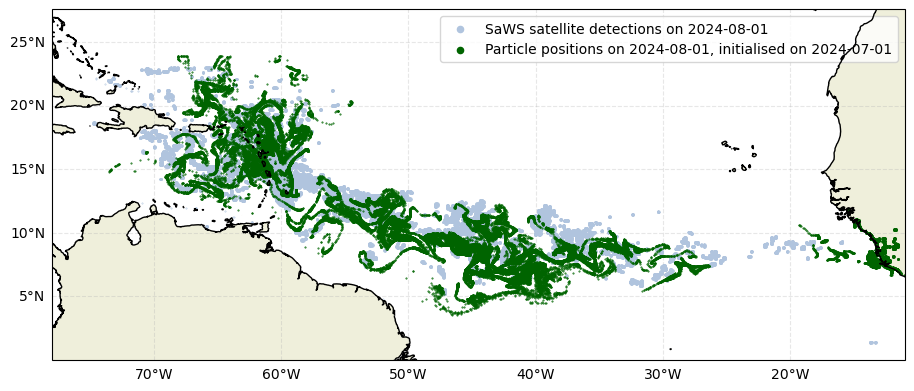

In [ ]:
ds = xr.open_zarr(filename).dropna(dim='obs', how='all')

fig = plt.figure(figsize = (11,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

satplot = ax.scatter(sarg_final_lon, sarg_final_lat, s = 0.11, c='lightsteelblue', label='SaWS satellite detections on 2024-08-01',zorder=6)
label = f'Particle positions on {ds.time[0, -1].values.astype("datetime64[D]")}, initialised on {ds.time[0, 0].values.astype("datetime64[D]")}'
eplot = ax.scatter(ds.lon[:,-1], ds.lat[:,-1], s = 0.2 ,color='darkgreen', label = label ,zorder=7)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=8)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-78, -11, 0, 24])
leg = ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([20])

fig.savefig('Figure2.pdf', bbox_inches='tight', dpi=300)

plt.show()